# 10주차: 로지스틱 회귀 II
## Chain Rule로 Gradient 유도, 결정 경계

**영상 강의용 노트북** | 이론(50분) + 익히기(25분)

---

### 잠깐!!! — 우리가 풀고 있는 문제가 뭐였죠?

수식을 따라가다 보면 원래 목적을 잊기 쉽습니다. 아파트 예시로 다시 잡아봅니다.

---

**선형회귀: 아파트 가격 예측**

| 면적 (㎡) | 지하철까지 (분) | 실거래가 (억) |
|:---:|:---:|:---:|
| 84 | 5 | 12.5 |
| 59 | 12 | 8.2 |
| 112 | 3 | 17.8 |
| 76 | 20 | 7.9 |
| 99 | 8 | 14.1 |
| 45 | 25 | 5.3 |
| 130 | 2 | 21.0 |
| 68 | 15 | 8.8 |
| 84 | 10 | 11.2 |
| 59 | 7 | 9.6 |

$$\hat{y} = w_0 + w_1 \times \text{면적} + w_2 \times \text{지하철}$$

- **출력:** 실수 (아파트 가격)
- **결정해야 할 변수:** $w_0,\ w_1,\ w_2$ — 총 3개

---

**로지스틱 회귀: 가성비 아파트 여부 분류**

| 면적 (㎡) | 지하철까지 (분) | 판매가 (억) | 가성비? |
|:---:|:---:|:---:|:---:|
| 84 | 5 | 10.0 | ✅ 1 |
| 59 | 12 | 9.5 | ❌ 0 |
| 112 | 3 | 15.0 | ✅ 1 |
| 76 | 20 | 9.8 | ❌ 0 |
| 99 | 8 | 11.5 | ✅ 1 |
| 45 | 25 | 6.8 | ❌ 0 |
| 130 | 2 | 17.0 | ✅ 1 |
| 68 | 15 | 10.5 | ❌ 0 |
| 84 | 10 | 9.0 | ✅ 1 |
| 59 | 7 | 11.0 | ❌ 0 |

$$\hat{p} = \sigma(w_0 + w_1 \times \text{면적} + w_2 \times \text{지하철} + w_3 \times \text{판매가})$$

- **출력:** 0~1 사이 확률 ($\hat{p} \geq 0.5$ 이면 가성비 아파트)
- **결정해야 할 변수:** $w_0,\ w_1,\ w_2,\ w_3$ — 총 4개

---

> **핵심 차이:**
> 선형회귀는 "얼마?"를 맞히고, 로지스틱 회귀는 "예/아니오?"를 맞힙니다.
> 결정해야 할 변수 $\mathbf{w}$ 의 역할은 동일합니다 — gradient descent로 찾습니다.

## 🔦 Aha Moment — 모델은 데이터를 어떻게 가르는가?

아래 코드를 실행하면, 학습이 진행되면서 **결정 경계**가 어떻게 움직이는지 볼 수 있습니다.

지금은 *"어떻게 이런 선이 그려지는가?"* 라는 질문만 열어두세요. 수업 끝에 답합니다.

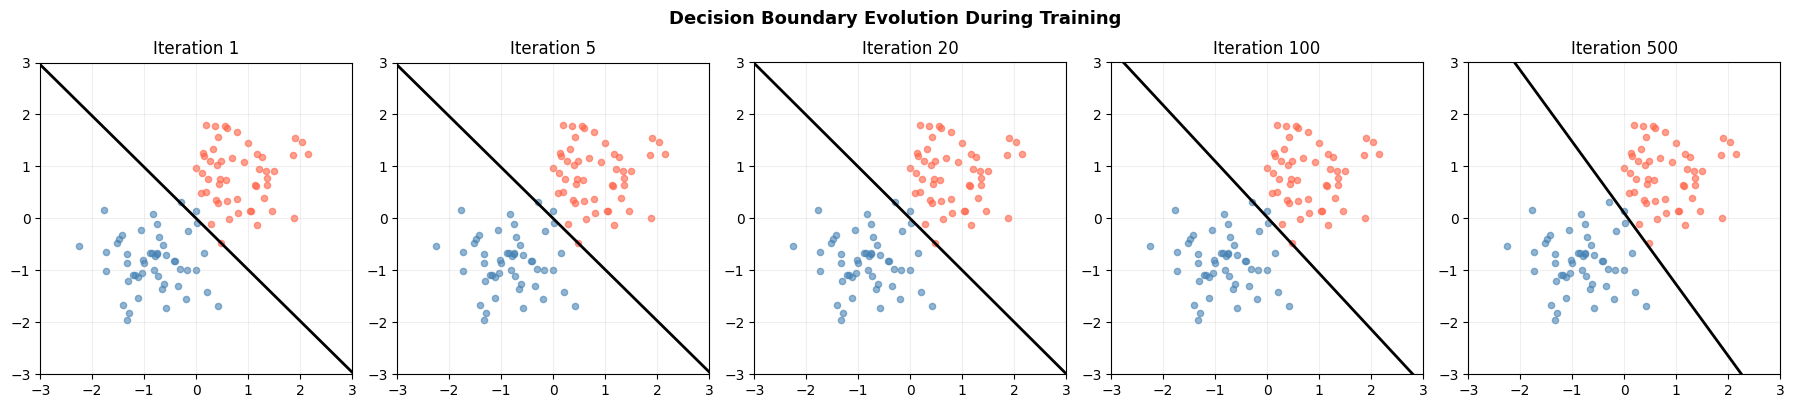

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# 두 클래스 데이터 생성
np.random.seed(0)
n = 100
X0 = np.random.randn(n//2, 2) + np.array([-1.5, -1.5])
X1 = np.random.randn(n//2, 2) + np.array([ 1.5,  1.5])
X_raw = np.vstack([X0, X1])
y = np.array([0]*(n//2) + [1]*(n//2), dtype=float)

# 표준화(Standardization)
mu  = X_raw.mean(axis=0)
std = X_raw.std(axis=0)
X_std = (X_raw - mu) / std
X_b   = np.hstack([np.ones((n, 1)), X_std])

def logistic_gd(X, y, lr=0.5, n_iter=500):
    w = np.zeros(X.shape[1])
    history = []
    for t in range(n_iter):
        p_hat = sigmoid(X @ w)
        grad  = X.T @ (p_hat - y) / len(y)
        w     = w - lr * grad
        if t+1 in [1, 5, 20, 100, 500]:
            history.append((t+1, w.copy()))
    return w, history

w_opt, w_history = logistic_gd(X_b, y)

# 결정 경계 이동 시각화
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
x1r = np.linspace(-3, 3, 200)

for ax, (it, w) in zip(axes, w_history):
    ax.scatter(X_std[y==0,0], X_std[y==0,1], c='steelblue', alpha=0.6, s=20)
    ax.scatter(X_std[y==1,0], X_std[y==1,1], c='tomato',    alpha=0.6, s=20)
    if abs(w[2]) > 1e-6:
        x2db = -(w[1]*x1r + w[0]) / w[2]
        ax.plot(x1r, x2db, 'k-', linewidth=2)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_title(f'Iteration {it}')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

plt.suptitle('Decision Boundary Evolution During Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> 경계선 하나가 학습과 함께 회전하며 두 클래스를 나눕니다.
> - **왜 직선인가?** → 섹션 5에서 수학적으로 설명합니다
> - **항상 직선이어야 하는가?** → 섹션 5 후반부에서 한계를 확인합니다

---

## 섹션 1. 복습: 로지스틱 회귀의 전체 구조

### 계산 흐름 (Forward Pass)

| 단계 | &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;연산&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 의미 |
|:---:|---|---|
| ① | $z = \mathbf{w}^T \mathbf{x} = w_0 + w_1 x_1 + \cdots + w_d x_d$ | 선형 결합 |
| ② | $\hat{p} = \sigma(z) = \dfrac{1}{1+e^{-z}}$ | 확률로 변환 |
| ③ | $L = -[y \log \hat{p} + (1-y) \log(1-\hat{p})]$ | BCE 손실 |

8주차에서 gradient 공식 $\dfrac{\partial L}{\partial w_i} = (\hat{p}-y)\,x_i$ 를 결과로만 사용했습니다.

오늘은 이것을 **chain rule로 직접 유도**합니다.

$$\frac{\partial L}{\partial w_i}
= \underbrace{\frac{\partial L}{\partial \hat{p}}}_{\text{①}}
\cdot \underbrace{\frac{\partial \hat{p}}{\partial z}}_{\text{②}}
\cdot \underbrace{\frac{\partial z}{\partial w_i}}_{\text{③}}$$

---
## 섹션 2. Chain Rule 유도 — 세 조각

### 조각 ①: $\dfrac{\partial L}{\partial \hat{p}}$

6주차에서 배운 로그 미분 $\dfrac{d}{dx}\log x = \dfrac{1}{x}$ 을 적용합니다.

$$\frac{\partial L}{\partial \hat{p}}
= \frac{\partial}{\partial \hat{p}}\Bigl(-y\log\hat{p} - (1-y)\log(1-\hat{p})\Bigr)
= -\frac{y}{\hat{p}} + \frac{1-y}{1-\hat{p}}$$

통분합니다.

$$= \frac{-y(1-\hat{p}) + (1-y)\hat{p}}{\hat{p}(1-\hat{p})}
= \frac{\hat{p} - y}{\hat{p}(1-\hat{p})}$$

> **패턴:** 분자가 $\hat{p}-y$ 입니다. 예측이 정답보다 크면 양수(손실 증가 방향).

---

### 조각 ②: $\dfrac{\partial \hat{p}}{\partial z}$ — 시그모이드 도함수

6주차 결과를 빠르게 복습합니다.

$$\frac{d\sigma}{dz}
= \frac{e^{-z}}{(1+e^{-z})^2}
= \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}}
= \sigma(z)\cdot(1-\sigma(z))$$

$$\boxed{\frac{d\sigma}{dz} = \hat{p}(1-\hat{p})}$$

> 도함수가 시그모이드 자신으로 표현됩니다. 이미 계산한 $\hat{p}$ 을 재사용할 수 있습니다.

---

### 조각 ③: $\dfrac{\partial z}{\partial w_i}$

$$z = w_0 x_0 + w_1 x_1 + \cdots + w_i x_i + \cdots$$

$w_i$ 이외의 항은 상수이므로:

$$\frac{\partial z}{\partial w_i} = x_i$$

---
## 섹션 3. 세 조각 조립 — 약분

$$\frac{\partial L}{\partial w_i}
= \underbrace{\frac{\hat{p}-y}{\color{crimson}{\hat{p}(1-\hat{p})}}}_{\text{①}}
\cdot \underbrace{\color{crimson}{\hat{p}(1-\hat{p})}}_{\text{②}}
\cdot \underbrace{x_i}_{\text{③}}$$

빨간 부분이 **정확히 약분**됩니다.

$$\boxed{\frac{\partial L}{\partial w_i} = (\hat{p} - y)\, x_i}$$

> **Aha Moment 닫기:**
> 시그모이드의 도함수 $\hat{p}(1-\hat{p})$ 가 BCE 분모와 같기 때문에 약분이 일어납니다.
> 이것이 시그모이드와 BCE가 "쌍"으로 설계된 수학적 이유입니다.

### 벡터 표기로 확장

샘플 하나:
$$\nabla_{\mathbf{w}} L = (\hat{p} - y)\,\mathbf{x}$$

$n$개 전체 (배치 gradient):
$$\nabla_{\mathbf{w}} \mathcal{L} = \frac{1}{n}\mathbf{X}^T(\hat{\mathbf{p}} - \mathbf{y})$$

> **5주차 패턴 재등장:** 선형회귀의 $\mathbf{X}^T(\hat{\mathbf{y}}-\mathbf{y})$ 와 구조가 같습니다.
> 활성 함수(시그모이드)가 추가되었을 뿐, gradient의 뼈대는 동일합니다.

##[참고]
**특성 3개 (d=3), 샘플 1개일 때**

$$\nabla_{\mathbf{w}} L = (\hat{p} - y)\,\mathbf{x}
= (\hat{p} - y)
\begin{pmatrix} 1 \\ x_1 \\ x_2 \\ x_3 \end{pmatrix}
=
\begin{pmatrix} \hat{p}-y \\ (\hat{p}-y)\,x_1 \\ (\hat{p}-y)\,x_2 \\ (\hat{p}-y)\,x_3 \end{pmatrix}$$

gradient는 $\mathbf{w}$ 와 같은 shape인 **4차원 벡터**입니다.  
각 원소 = 오차 $(\hat{p}-y)$ × 해당 특성값.

**같은 데이터, 샘플 5개일 때**

$$\mathbf{X} =
\begin{pmatrix}
1 & x_1^{(1)} & x_2^{(1)} & x_3^{(1)} \\
1 & x_1^{(2)} & x_2^{(2)} & x_3^{(2)} \\
1 & x_1^{(3)} & x_2^{(3)} & x_3^{(3)} \\
1 & x_1^{(4)} & x_2^{(4)} & x_3^{(4)} \\
1 & x_1^{(5)} & x_2^{(5)} & x_3^{(5)}
\end{pmatrix}_{5 \times 4}
\qquad
\hat{\mathbf{p}} - \mathbf{y} =
\begin{pmatrix}
\hat{p}^{(1)} - y^{(1)} \\
\hat{p}^{(2)} - y^{(2)} \\
\hat{p}^{(3)} - y^{(3)} \\
\hat{p}^{(4)} - y^{(4)} \\
\hat{p}^{(5)} - y^{(5)}
\end{pmatrix}_{5 \times 1}$$

$$\nabla_{\mathbf{w}} \mathcal{L}
= \frac{1}{5}\,\mathbf{X}^T(\hat{\mathbf{p}} - \mathbf{y})
= \frac{1}{5}
\begin{pmatrix}
\sum_{i=1}^{5}(\hat{p}^{(i)}-y^{(i)}) \\
\sum_{i=1}^{5}(\hat{p}^{(i)}-y^{(i)})\,x_1^{(i)} \\
\sum_{i=1}^{5}(\hat{p}^{(i)}-y^{(i)})\,x_2^{(i)} \\
\sum_{i=1}^{5}(\hat{p}^{(i)}-y^{(i)})\,x_3^{(i)}
\end{pmatrix}_{4 \times 1}$$

결과는 샘플 수와 무관하게 여전히 **4차원 벡터** — $\mathbf{w}$ 와 shape이 같습니다.

> **Shape 추적:** $(4 \times 5) \cdot (5 \times 1) = (4 \times 1)$ ✓  
> $\mathbf{X}^T$ 의 전치가 왜 필요한지 shape만 봐도 알 수 있습니다.

In [2]:
# 수치 미분으로 유도 결과 검증
def bce_loss_single(w, x, y):
    p = sigmoid(np.dot(w, x)); eps = 1e-12
    return -(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))

w_t = np.array([0.3, -0.5, 0.8])
x_t = np.array([1.0,  2.0, -1.0])
y_t = 1.0

p_hat         = sigmoid(np.dot(w_t, x_t))
grad_analytic = (p_hat - y_t) * x_t          # 유도 결과

h = 1e-5
grad_numeric = np.zeros(3)
for i in range(3):
    wp = w_t.copy(); wp[i] += h
    wm = w_t.copy(); wm[i] -= h
    grad_numeric[i] = (bce_loss_single(wp, x_t, y_t)
                     - bce_loss_single(wm, x_t, y_t)) / (2*h)

print("Analytic gradient:", np.round(grad_analytic, 6))
print("Numeric  gradient:", np.round(grad_numeric,  6))
print("Max difference:   ", np.max(np.abs(grad_analytic - grad_numeric)))

Analytic gradient: [-0.817574 -1.635149  0.817574]
Numeric  gradient: [-0.817574 -1.635149  0.817574]
Max difference:    2.5900392941480277e-11


---
## 섹션 4. 경사하강법 구현 (간략)

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \cdot \frac{1}{n}\mathbf{X}^T(\hat{\mathbf{p}} - \mathbf{y})$$

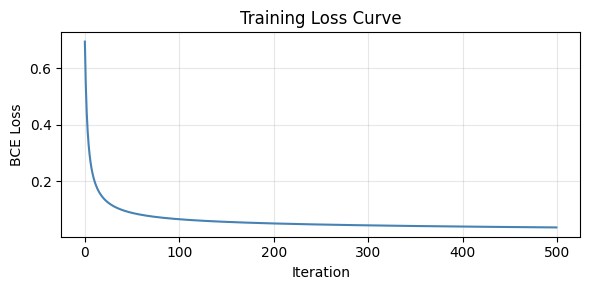

Final loss: 0.0378


In [3]:
def logistic_gd_full(X, y, lr=0.5, n_iter=500):
    w = np.zeros(X.shape[1]); losses = []
    for _ in range(n_iter):
        p_hat = sigmoid(X @ w); eps = 1e-12
        losses.append(-np.mean(y*np.log(p_hat+eps) + (1-y)*np.log(1-p_hat+eps)))
        w = w - lr * (X.T @ (p_hat - y) / len(y))
    return w, losses

w_opt, losses = logistic_gd_full(X_b, y)

plt.figure(figsize=(6, 3))
plt.plot(losses, color='steelblue')
plt.xlabel('Iteration'); plt.ylabel('BCE Loss')
plt.title('Training Loss Curve'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Final loss: {losses[-1]:.4f}")

---
## 섹션 5. 결정 경계 ★ (핵심)

### 5-1. 왜 결정 경계가 직선인가?

모델은 $\hat{p} \geq 0.5$ 이면 클래스 1로 예측합니다.

$$\sigma(z) = 0.5 \iff z = 0 \iff w_0 + w_1 x_1 + w_2 x_2 = 0$$

$x_2$ 를 $x_1$ 의 함수로 풀면:

$$x_2 = -\frac{w_1}{w_2}\,x_1 - \frac{w_0}{w_2}$$

이것은 기울기 $-\dfrac{w_1}{w_2}$, 절편 $-\dfrac{w_0}{w_2}$ 인 **직선 방정식**입니다.

> **핵심:** 결정 경계가 직선인 이유는 $z = \mathbf{w}^T \mathbf{x}$ 가 **선형 함수**이기 때문입니다.
> 시그모이드는 직선을 곡선으로 만들지 않습니다. 그냥 0~1 사이로 눌러줄 뿐입니다.

### 5-2. 학습 과정에서 결정 경계는 어떻게 움직이는가?

각 이터레이션에서 $(w_0, w_1, w_2)$ 가 바뀔 때마다:

$$\text{기울기} = -\frac{w_1}{w_2}, \qquad \text{절편} = -\frac{w_0}{w_2}$$

가 함께 바뀝니다. 즉 결정 경계가 **회전하고 이동**합니다.

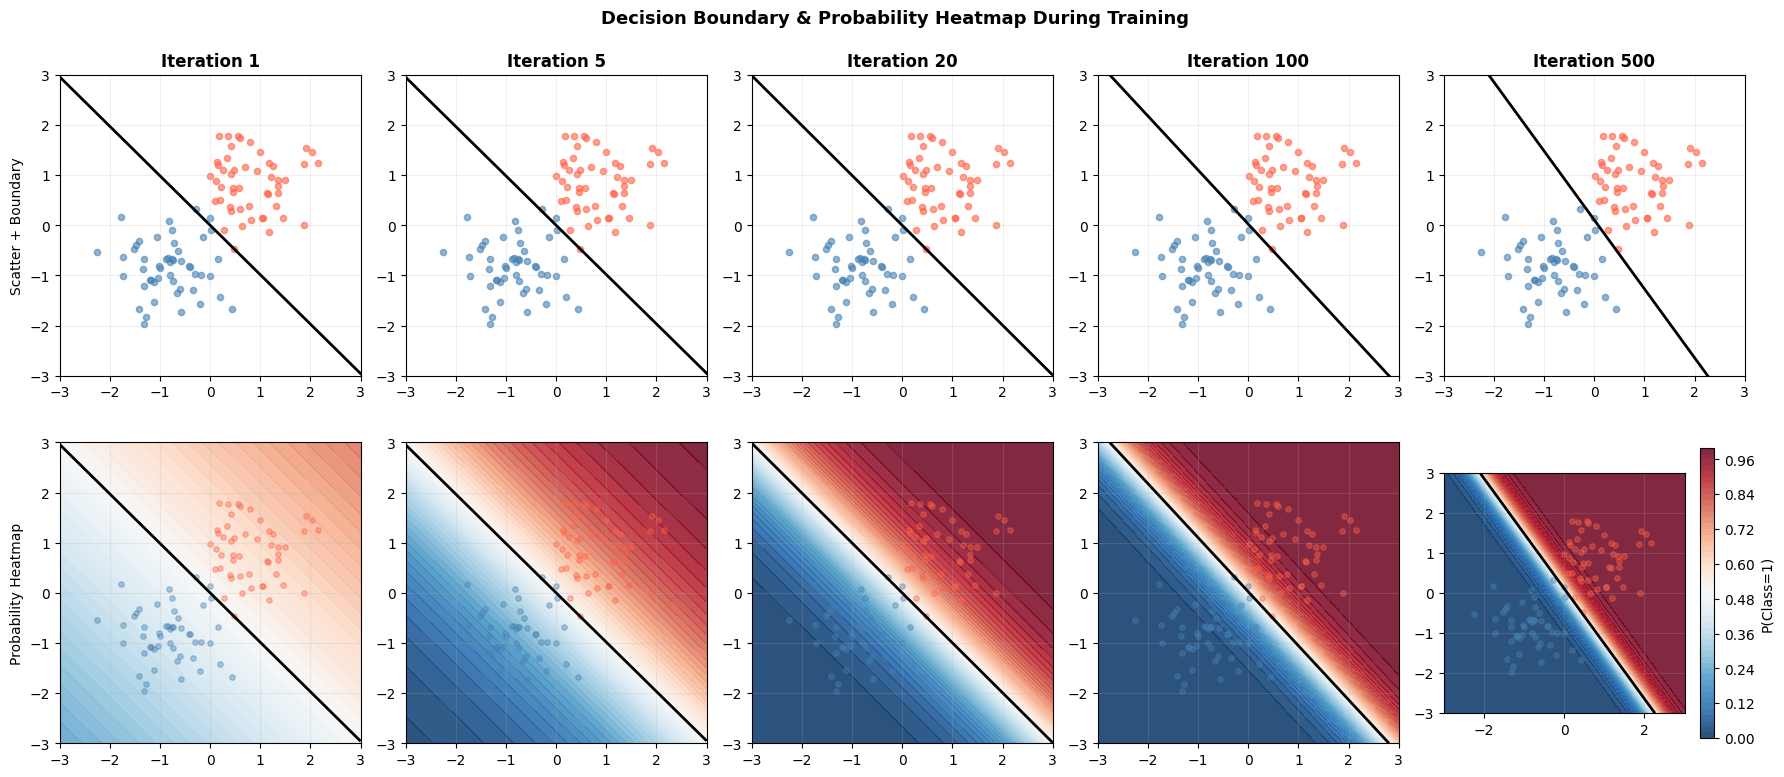

In [4]:
# Decision boundary evolution + probability heatmap
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
# 2행 5열 subplot: 상단행 = scatter+경계선, 하단행 = 확률 히트맵
# 열 하나 = 특정 iteration의 스냅샷

iterations_to_show = [1, 5, 20, 100, 500]  # 시각화할 iteration 시점
x1r = np.linspace(-3, 3, 200)              # 결정 경계 직선을 그릴 x1 범위

# ── 히트맵용 격자 생성 ──────────────────────────────────────────────────────
# 120×120 격자점을 만들어 각 점에서 P(Class=1) 을 계산
xx1, xx2 = np.meshgrid(np.linspace(-3, 3, 120), np.linspace(-3, 3, 120))
# xx1, xx2: 각각 (120,120) 행렬 — 격자의 x1좌표, x2좌표

Xg = np.c_[np.ones(xx1.ravel().shape), xx1.ravel(), xx2.ravel()]  #편향트릭(bias) 포함
# xx1.ravel(): (120×120,) = (14400,) 로 펼치기
# np.c_[...]: bias열(1) + x1열 + x2열 → shape (14400, 3)
# sigmoid(Xg @ w) 로 14400개 격자점의 예측 확률을 한 번에 계산

# ── 가중치 스냅샷 수집 ──────────────────────────────────────────────────────
def logistic_gd_snap(X, y, lr=0.5, n_iter=500, snapshots=None):
    """
    경사하강법을 실행하면서 특정 iteration의 가중치를 저장.
    snapshots: 저장할 iteration 번호 리스트 (예: [1, 5, 20, 100, 500])
    반환값: {iteration번호: w벡터} 딕셔너리
    """
    w = np.zeros(X.shape[1])  # 가중치 초기화 (모두 0)
    snaps = {}  # snapshots 지점에서 가중치 저장할 딕셔너리 초기화
    for t in range(1, n_iter+1):
        p_hat = sigmoid(X @ w)                   # forward: 예측 확률
        w = w - lr * (X.T @ (p_hat - y) / len(y))  # gradient descent 업데이트
        if t in snapshots:
            snaps[t] = w.copy()  # 해당 시점의 가중치를 딕셔너리에 추가하여 저장 (.copy() 필수 — 참조가 아닌 값 복사)
    return snaps

snaps = logistic_gd_snap(X_b, y, snapshots=iterations_to_show)

# ── 각 iteration 시점별 시각화 ────────────────────────────────────────────────
for col, it in enumerate(iterations_to_show):  # col: 0,1,2,3,4   it: 1, 5, 20, 100, 500
    w = snaps[it]  # 해당 시점의 가중치 [w0, w1, w2]

    # ── 상단행: scatter + 결정 경계 직선 ──
    ax = axes[0, col]
    ax.scatter(X_std[y==0,0], X_std[y==0,1], c='steelblue', alpha=0.6, s=20, label='Class 0')
    ax.scatter(X_std[y==1,0], X_std[y==1,1], c='tomato',    alpha=0.6, s=20, label='Class 1')

    if abs(w[2]) > 1e-6:  # w2 ≈ 0이면 수직선(분모=0)이라 계산 불가 → 건너뜀
        # 결정 경계: w0 + w1*x1 + w2*x2 = 0  →  x2 = -(w1*x1 + w0) / w2
        x2db = -(w[1]*x1r + w[0]) / w[2]
        ax.plot(x1r, x2db, 'k-', linewidth=2)

    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
    ax.set_title(f'Iteration {it}', fontweight='bold')
    ax.grid(True, alpha=0.2)
    if col == 0: ax.set_ylabel('Scatter + Boundary')  # 맨 왼쪽 열에만 y축 레이블

    # ── 하단행: 확률 히트맵 ──
    ax = axes[1, col]

    pg = sigmoid(Xg @ w).reshape(xx1.shape)  #각 grid(격자점) 위치의 확률 계산한 후 2D로 변환
    # Xg @ w: 14400개 격자점의 z값 계산, shape (14400,)
    # sigmoid(...): 각 격자점의 P(Class=1), shape (14400,)
    # .reshape(xx1.shape): 다시 (120,120)으로 — contourf가 2D 행렬을 요구

    im = ax.contourf(xx1, xx2, pg, levels=50, cmap='RdBu_r', alpha=0.85, vmin=0, vmax=1)
    # contourf: 격자점 확률값을 50단계 색상으로 채움
    # RdBu_r: 파랑(0, 클래스0) → 빨강(1, 클래스1) 색상맵

    ax.contour(xx1, xx2, pg, levels=[0.5], colors='black', linewidths=2)
    # contour: p=0.5 등고선만 검은 실선으로 — 이것이 결정 경계

    ax.scatter(X_std[y==0,0], X_std[y==0,1], c='steelblue', alpha=0.4, s=15)
    ax.scatter(X_std[y==1,0], X_std[y==1,1], c='tomato',    alpha=0.4, s=15)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    if col == 0: ax.set_ylabel('Probability Heatmap')

# colorbar는 마지막 im 객체 기준으로 생성 (모든 subplot이 동일한 vmin/vmax 사용)
plt.colorbar(im, ax=axes[1,-1], label='P(Class=1)', shrink=0.8)
plt.suptitle('Decision Boundary & Probability Heatmap During Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **관찰:**
> - **Iteration 1:** 경계선이 거의 수평, 히트맵이 거의 균등 (가중치 ≈ 0, $\hat{p} \approx 0.5$)
> - **Iteration 20:** 경계선이 회전하며 두 클래스를 나누기 시작
> - **Iteration 500:** 경계선이 두 클래스 사이를 깔끔하게 가름
> - **히트맵:** 경계에서 멀어질수록 확신(0 또는 1에 가까운 확률)이 강해짐

In [15]:
xx1, xx2 = np.meshgrid(np.linspace(-3, 3, 7), np.linspace(-1, 1, 5))
print(xx1)
print(xx2)

[[-3. -2. -1.  0.  1.  2.  3.]
 [-3. -2. -1.  0.  1.  2.  3.]
 [-3. -2. -1.  0.  1.  2.  3.]
 [-3. -2. -1.  0.  1.  2.  3.]
 [-3. -2. -1.  0.  1.  2.  3.]]
[[-1.  -1.  -1.  -1.  -1.  -1.  -1. ]
 [-0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5]
 [ 0.   0.   0.   0.   0.   0.   0. ]
 [ 0.5  0.5  0.5  0.5  0.5  0.5  0.5]
 [ 1.   1.   1.   1.   1.   1.   1. ]]


In [18]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
# Resulting in 3x2 matrix
result = np.c_[a, b]
print(result)

[[1 4]
 [2 5]
 [3 6]]


### 5-3. 가중치 벡터 **w**는 결정 경계에 수직

결정 경계 위의 임의의 두 점 $\mathbf{x}_A$, $\mathbf{x}_B$ 는 모두 $z = 0$ 을 만족합니다.

$$w_0 + w_1 x_1^{(A)} + w_2 x_2^{(A)} = 0$$
$$w_0 + w_1 x_1^{(B)} + w_2 x_2^{(B)} = 0$$

두 식을 빼면 $w_0$ 가 사라집니다.

$$(w_1, w_2) \cdot (\mathbf{x}_A - \mathbf{x}_B) = 0$$

$\mathbf{x}_A - \mathbf{x}_B$ 는 결정 경계를 따라가는 벡터이고, 내적이 0이므로
$(w_1, w_2)$ 는 결정 경계에 **수직**입니다.

$w_0$ 는 경계선의 **방향**이 아니라 **위치(절편)** 를 결정하기 때문에,
$w_0$ 가 얼마이든 수직 관계는 변하지 않습니다.

- $\mathbf{w} \cdot \mathbf{x} > 0$ → 클래스 1 방향
- $\mathbf{w} \cdot \mathbf{x} < 0$ → 클래스 0 방향

이것은 5주차에서 배운 **내적 = 투영**과 같은 개념입니다.

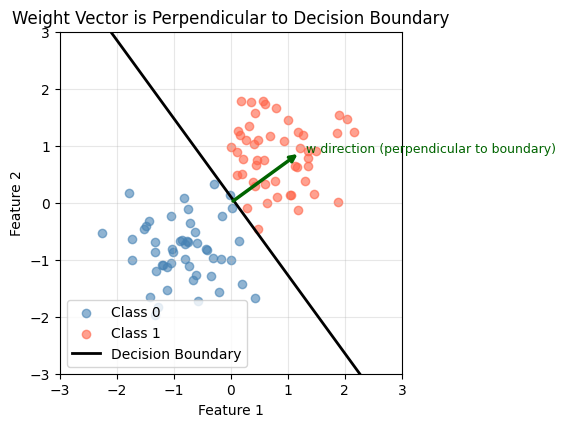

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(X_std[y==0,0], X_std[y==0,1], c='steelblue', label='Class 0', alpha=0.6)
ax.scatter(X_std[y==1,0], X_std[y==1,1], c='tomato',    label='Class 1', alpha=0.6)

x1r  = np.linspace(-3, 3, 200)
x2db = -(w_opt[1]*x1r + w_opt[0]) / w_opt[2]
ax.plot(x1r, x2db, 'k-', linewidth=2, label='Decision Boundary')

scale = 1.5 / np.sqrt(w_opt[1]**2 + w_opt[2]**2)
ax.annotate('', xy=(scale*w_opt[1], scale*w_opt[2]), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2.5))
ax.text(scale*w_opt[1]+0.1, scale*w_opt[2], 'w direction (perpendicular to boundary)',
        color='darkgreen', fontsize=9)

ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.set_title('Weight Vector is Perpendicular to Decision Boundary')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

---
### 5-4. 로지스틱 회귀의 한계 — 선형 분리 불가능한 데이터

결정 경계가 **항상 직선**이라는 것은 근본적인 제약입니다.

아래 두 데이터셋에서 어떻게 실패하는지 확인합니다.

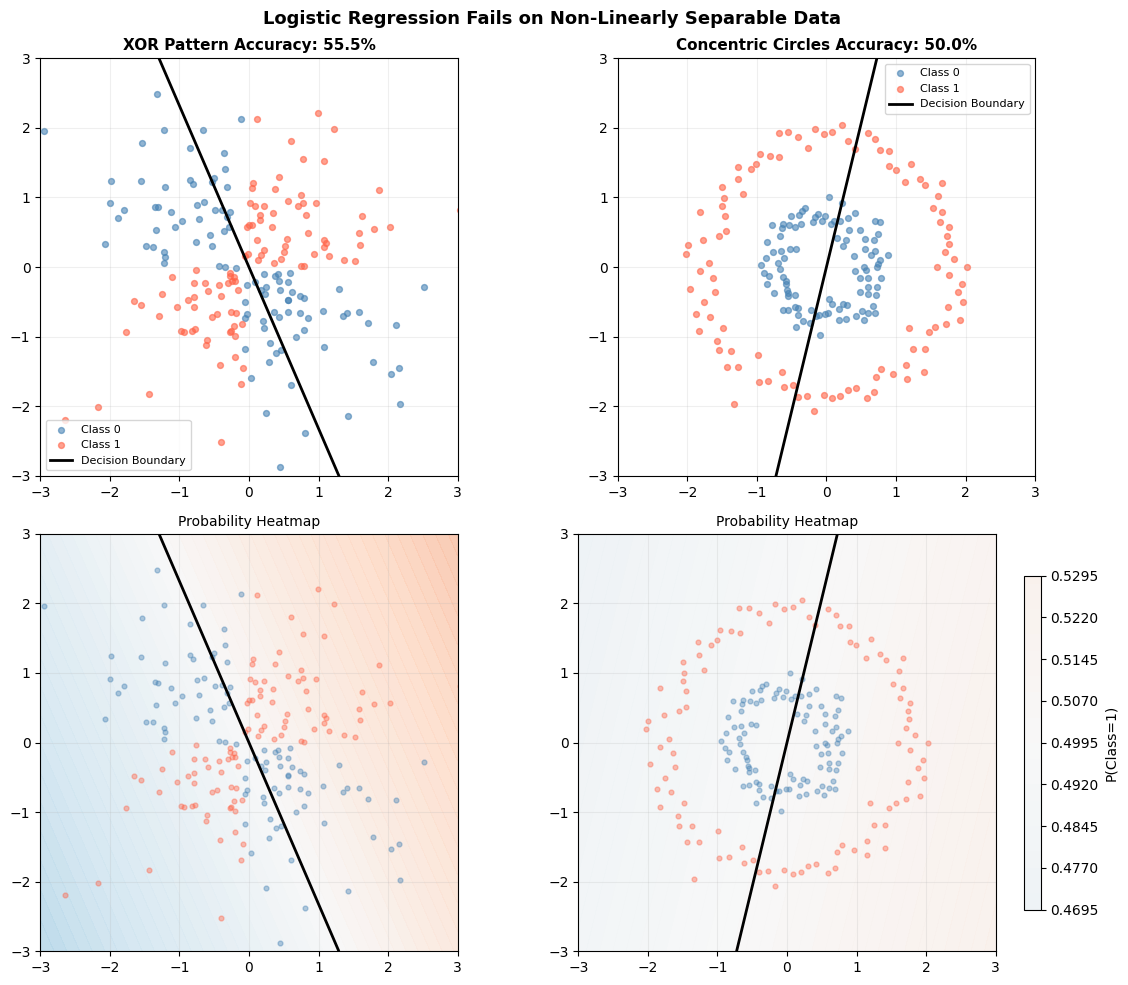

In [6]:
# Case 1: XOR 패턴
np.random.seed(1)
n2 = 200
X_xor = np.random.randn(n2, 2) * 0.7
y_xor = ((X_xor[:,0] * X_xor[:,1]) > 0).astype(float)

# Case 2: 동심원 패턴
theta  = np.linspace(0, 2*np.pi, n2//2)
r_in   = 0.8 + np.random.randn(n2//2) * 0.15
r_out  = 2.0 + np.random.randn(n2//2) * 0.15
X_circ = np.vstack([
    np.c_[r_in  * np.cos(theta), r_in  * np.sin(theta)],
    np.c_[r_out * np.cos(theta), r_out * np.sin(theta)]
])
y_circ = np.array([0]*(n2//2) + [1]*(n2//2), dtype=float)

datasets = [
    (X_xor,  y_xor,  'XOR Pattern'),
    (X_circ, y_circ, 'Concentric Circles'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for col, (X_d, y_d, title) in enumerate(datasets):
    # 표준화
    mu_d  = X_d.mean(axis=0); std_d = X_d.std(axis=0)
    Xs_d  = (X_d - mu_d) / std_d
    Xb_d  = np.hstack([np.ones((len(y_d),1)), Xs_d])

    # 로지스틱 회귀 학습
    w_d, _ = logistic_gd_full(Xb_d, y_d, lr=0.3, n_iter=1000)
    p_pred  = sigmoid(Xb_d @ w_d)
    acc     = np.mean((p_pred >= 0.5) == y_d)

    # heatmap grid
    xx1, xx2 = np.meshgrid(np.linspace(-3, 3, 150), np.linspace(-3, 3, 150))
    Xg_d = np.c_[np.ones(xx1.ravel().shape), xx1.ravel(), xx2.ravel()]
    pg_d = sigmoid(Xg_d @ w_d).reshape(xx1.shape)

    # Top: scatter + boundary
    ax = axes[0, col]
    ax.scatter(Xs_d[y_d==0,0], Xs_d[y_d==0,1], c='steelblue', alpha=0.6, s=18, label='Class 0')
    ax.scatter(Xs_d[y_d==1,0], Xs_d[y_d==1,1], c='tomato',    alpha=0.6, s=18, label='Class 1')
    if abs(w_d[2]) > 1e-6:
        x1r_d = np.linspace(-3, 3, 200)
        x2db_d = -(w_d[1]*x1r_d + w_d[0]) / w_d[2]
        ax.plot(x1r_d, x2db_d, 'k-', linewidth=2, label='Decision Boundary')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
    ax.set_title(f'{title} Accuracy: {acc:.1%}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

    # Bottom: probability heatmap
    ax = axes[1, col]
    im = ax.contourf(xx1, xx2, pg_d, levels=50, cmap='RdBu_r', alpha=0.85, vmin=0, vmax=1)
    ax.contour(xx1, xx2, pg_d, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(Xs_d[y_d==0,0], Xs_d[y_d==0,1], c='steelblue', alpha=0.4, s=12)
    ax.scatter(Xs_d[y_d==1,0], Xs_d[y_d==1,1], c='tomato',    alpha=0.4, s=12)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
    ax.set_title('Probability Heatmap', fontsize=10)
    ax.grid(True, alpha=0.2)

plt.colorbar(im, ax=axes[1,-1], label='P(Class=1)', shrink=0.8)
plt.suptitle('Logistic Regression Fails on Non-Linearly Separable Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **관찰:**
> - **XOR 패턴 (~50% 정확도):** 어떤 직선을 그어도 두 클래스를 분리할 수 없습니다.
>   히트맵이 반으로 갈라진 형태 — 데이터 구조를 전혀 포착하지 못합니다.
> - **동심원 패턴 (~50% 정확도):** 경계가 원형인데, 직선은 원을 그릴 수 없습니다.
> - 두 경우 모두 **동전 던지기 수준**의 성능입니다.

### 5-5. 그렇다면 어떻게 해야 할까? → 신경망 예고

**문제의 본질:**

$$z = \mathbf{w}^T \mathbf{x} \quad \text{(선형)}$$

선형 함수를 아무리 합성해도 여전히 선형입니다.

$$\text{선형} \circ \text{선형} \circ \text{선형} = \text{여전히 선형}$$

**해결 방법:**

선형 변환 사이에 **비선형 함수(활성 함수)** 를 삽입합니다.

$$\mathbf{x}
\xrightarrow{\mathbf{W}_1}
z_1
\xrightarrow{\text{ReLU}}
a_1
\xrightarrow{\mathbf{W}_2}
z_2
\xrightarrow{\sigma}
\hat{p}$$

이것이 **신경망(Neural Network)** 입니다. 13주차에서 이 구조를 수학적으로 분해합니다.

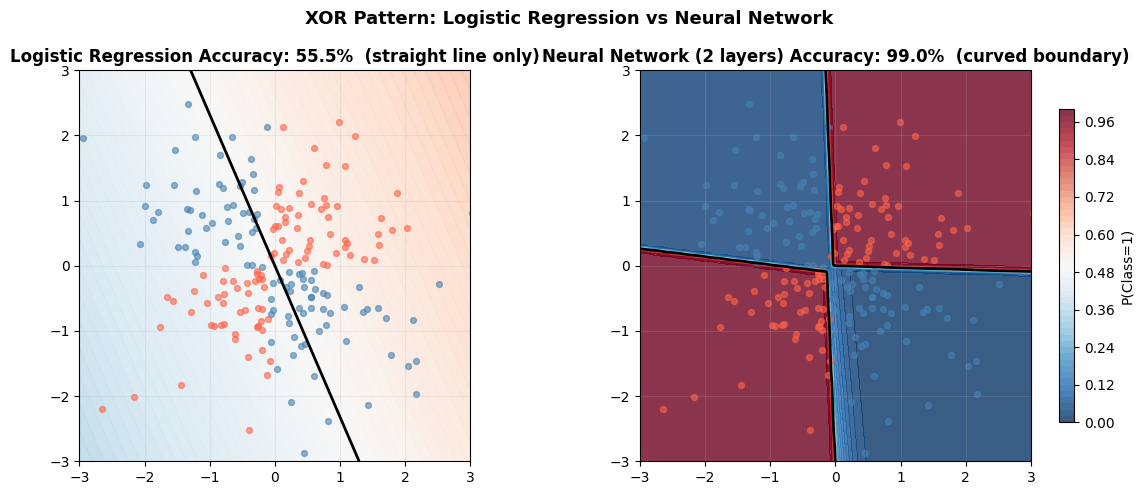

In [7]:
# 신경망 미리보기 — XOR 데이터에서 비선형 경계
def relu(z): return np.maximum(0, z)

def nn_forward(X, W1, b1, W2, b2):
    a1 = relu(X @ W1 + b1)
    return sigmoid((a1 @ W2 + b2).ravel())

def nn_train(X, y, hidden=8, lr=0.5, n_iter=3000):
    np.random.seed(42)
    d = X.shape[1]
    W1 = np.random.randn(d, hidden) * 0.5
    b1 = np.zeros(hidden)
    W2 = np.random.randn(hidden, 1) * 0.5
    b2 = np.zeros(1)
    for _ in range(n_iter):
        # forward
        z1 = X @ W1 + b1; a1 = relu(z1)
        p  = sigmoid((a1 @ W2 + b2).ravel())
        # backward (simplified)
        eps = 1e-12
        dp  = p - y
        dW2 = (a1.T @ dp.reshape(-1,1)) / len(y)
        db2 = dp.mean()
        da1 = (dp.reshape(-1,1) @ W2.T) * (z1 > 0)
        dW1 = (X.T @ da1) / len(y)
        db1 = da1.mean(axis=0)
        W1 -= lr*dW1; b1 -= lr*db1
        W2 -= lr*dW2; b2 -= lr*db2
    return W1, b1, W2, b2

# XOR 데이터로 비교
mu_x  = X_xor.mean(axis=0); std_x = X_xor.std(axis=0)
Xs_x  = (X_xor - mu_x) / std_x
Xb_x  = np.hstack([np.ones((len(y_xor),1)), Xs_x])

W1, b1, W2, b2 = nn_train(Xs_x, y_xor)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
xx1, xx2 = np.meshgrid(np.linspace(-3, 3, 150), np.linspace(-3, 3, 150))
Xg_x = np.c_[xx1.ravel(), xx2.ravel()]

# Logistic Regression
w_xor, _ = logistic_gd_full(Xb_x, y_xor, lr=0.3, n_iter=1000)
pg_lr = sigmoid(np.c_[np.ones(len(Xg_x)), Xg_x] @ w_xor).reshape(xx1.shape)
acc_lr = np.mean((sigmoid(Xb_x @ w_xor) >= 0.5) == y_xor)

ax = axes[0]
ax.contourf(xx1, xx2, pg_lr, levels=50, cmap='RdBu_r', alpha=0.8, vmin=0, vmax=1)
ax.contour(xx1, xx2, pg_lr, levels=[0.5], colors='black', linewidths=2)
ax.scatter(Xs_x[y_xor==0,0], Xs_x[y_xor==0,1], c='steelblue', alpha=0.6, s=18)
ax.scatter(Xs_x[y_xor==1,0], Xs_x[y_xor==1,1], c='tomato',    alpha=0.6, s=18)
ax.set_title(f'Logistic Regression Accuracy: {acc_lr:.1%}  (straight line only)', fontweight='bold')
ax.set_xlim(-3,3); ax.set_ylim(-3,3); ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

# Neural Network
pg_nn = nn_forward(Xg_x, W1, b1, W2, b2).reshape(xx1.shape)
acc_nn = np.mean((nn_forward(Xs_x, W1, b1, W2, b2) >= 0.5) == y_xor)

ax = axes[1]
im = ax.contourf(xx1, xx2, pg_nn, levels=50, cmap='RdBu_r', alpha=0.8, vmin=0, vmax=1)
ax.contour(xx1, xx2, pg_nn, levels=[0.5], colors='black', linewidths=2)
ax.scatter(Xs_x[y_xor==0,0], Xs_x[y_xor==0,1], c='steelblue', alpha=0.6, s=18)
ax.scatter(Xs_x[y_xor==1,0], Xs_x[y_xor==1,1], c='tomato',    alpha=0.6, s=18)
ax.set_title(f'Neural Network (2 layers) Accuracy: {acc_nn:.1%}  (curved boundary)', fontweight='bold')
ax.set_xlim(-3,3); ax.set_ylim(-3,3); ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

plt.colorbar(im, ax=axes[1], label='P(Class=1)', shrink=0.8)
plt.suptitle('XOR Pattern: Logistic Regression vs Neural Network', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **비교 요약:**
>
> | | 로지스틱 회귀 | 신경망 |
> |---|---|---|
> | 결정 경계 | 항상 직선 | 곡선 (임의 형태) |
> | XOR 정확도 | ~50% | ~99% |
> | 수학적 이유 | 선형 결합만 사용 | 선형 + 비선형 함수 합성 |
>
> 13주차에서 "비선형 함수 합성이 왜 가능한지"를 수학적으로 분해합니다.

---
## ✏️ 익히기 활동 (25분)

### 빈칸 1. 시그모이드 도함수

`sigmoid()`를 두 번 이상 호출하지 않고 이미 계산된 `p`를 재사용하세요.

In [ ]:
def sigmoid_derivative(z):
    p = sigmoid(z)
    return ______  # σ'(z) = σ(z)(1−σ(z))

### 빈칸 2. Gradient 계산

$$\nabla_{\mathbf{w}} \mathcal{L} = \dfrac{1}{n}\mathbf{X}^T(\hat{\mathbf{p}} - \mathbf{y})$$

In [ ]:
def compute_gradient(X, y, w):
    n     = X.shape[0]
    p_hat = sigmoid(X @ w)
    return ______  # (1/n) * X.T @ (p_hat - y)

### 빈칸 3. 결정 경계 직선

$w_0 + w_1 x_1 + w_2 x_2 = 0$ 에서 $x_2$ 를 구하세요.

In [ ]:
def decision_boundary_x2(x1_vals, w):
    return ______  # -(w[1]*x1_vals + w[0]) / w[2]

---
### 🐛 버그 잡기 (교실에서 팀 활동으로 해결)

아래 코드는 손실이 수렴하지 않습니다. 무엇이 잘못되었는지 찾아보세요.

In [ ]:
def buggy_logistic(X, y, lr=0.5, n_iter=300):
    n, d = X.shape; w = np.zeros(d); losses = []
    for _ in range(n_iter):
        p_hat = sigmoid(X @ w); eps = 1e-12
        losses.append(-np.mean(y*np.log(p_hat+eps)+(1-y)*np.log(1-p_hat+eps)))
        grad = X.T @ (y - p_hat) / n   # <- 여기 주목
        w    = w - lr * grad
    return losses

plt.figure(figsize=(6,3))
plt.plot(buggy_logistic(X_b, y), color='tomato')
plt.title('Buggy Loss Curve'); plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

> **힌트:** gradient 부호가 맞는지 확인하세요.
> 올바른 공식은 $\hat{p} - y$ 인가요, $y - \hat{p}$ 인가요?

---

## 🤖 LLM 파트너 가이드

**답을 바로 요청하지 말고, 왜 틀렸는지 먼저 물어보세요.**

**프롬프트 1 — Chain Rule 확인**
```
로지스틱 회귀 gradient를 chain rule로 이렇게 유도했는데 맞나요?
[내 계산 붙여넣기]
어느 단계에서 오류인지만 알려주세요. 정답은 아직 주지 마세요.
```

**프롬프트 2 — 결정 경계 직관**
```
로지스틱 회귀 결정 경계가 직선인 이유를 σ(z)=0.5 조건에서 출발해 설명해주세요.
XOR 데이터를 로지스틱 회귀로 분류하면 왜 실패하는지도 설명해주세요.
```

**프롬프트 3 — 신경망 연결**
```
로지스틱 회귀의 결정 경계는 항상 직선인데,
신경망은 왜 비선형 경계를 만들 수 있나요?
선형 변환과 비선형 활성 함수의 합성 관점에서 설명해주세요.
```

---

## 🔭 다음 주 예고 — 11주차: 엔트로피와 교차 엔트로피

8주차에서 BCE 손실을 MLE로 유도했습니다.
그런데 "왜 이 손실함수가 올바른가?"에 대한 더 깊은 답이 있습니다.

11주차에서는:
- **엔트로피 $H(p)$**: 불확실성의 수학적 측정
- **교차 엔트로피 $H(p, q)$**: 두 분포 사이의 거리
- **KL divergence**: 분포 간 차이
- **"MLE = 교차 엔트로피 최소화"** 의 수학적 증명

지금까지 손실함수로만 쓰던 $-\sum y \log \hat{p}$ 이 정보이론에서 어디서 나오는지 완성합니다.